# Лабораторна робота 1 — Дослідження даних з NumPy, Pandas та scikit-learn

**Набір даних:** `kc_house_data.csv`  
**Дозволені бібліотеки:** NumPy, Pandas, Matplotlib, scikit-learn (усі модулі)

## Налаштування — встановлення залежностей та імпорт

Запустіть комірку нижче один раз, щоб переконатись, що всі необхідні пакети встановлені.

In [1]:
# Встановлення залежностей (можна запускати повторно)
import sys
!{sys.executable} -m pip install numpy pandas matplotlib scikit-learn --quiet



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: C:\Users\nasti\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)


---
## Завдання 1 — Розминка з NumPy

**а)** Створіть масив NumPy з 10 000 значень, що підпорядковані нормальному розподілу N(0, 1). Обчисліть середнє, стандартне відхилення, мінімум і максимум за допомогою функцій NumPy — **без Python-циклів**.

**б)** Підрахуйте, скільки значень виходять за межі ±2 стандартних відхилення, використовуючи логічну індексацію. Яка це відсоткова частка? Порівняйте з теоретичним значенням ≈4,55 %.

In [9]:
# Завдання 1а — створіть масив і обчисліть статистику
rng = np.random.default_rng()
data = rng.normal(loc=0.0, scale=1.0, size=10000)
print(f"Розмір масиву: {data.size}")


mean_val = np.mean(data)
std_val = np.std(data)
min_val = np.min(data)
max_val = np.max(data)

print(f"Середнє (Mean): {mean_val:.4f}")
print(f"Стандартне відхилення (Std): {std_val:.4f}")
print(f"Мінімум (Min): {min_val:.4f}")
print(f"Максимум (Max): {max_val:.4f}")

Розмір масиву: 10000
Середнє (Mean): 0.0000
Стандартне відхилення (Std): 0.9948
Мінімум (Min): -4.0997
Максимум (Max): 4.2335


In [11]:
# Завдання 1б — підрахуйте викиди за допомогою логічної індексації
lower_bound = mean_val - 2 * std_val
upper_bound = mean_val + 2 * std_val

# Логічна індексація: створення "маски" для значень за межами
outliers_mask = (data < lower_bound) | (data > upper_bound)
outliers_count = np.sum(outliers_mask)
total_elements = len(data)
outliers_percentage = (outliers_count / total_elements) * 100

print(f"Кількість значень за межами ±2 ст. відхилень: {outliers_count}")
print(f"Практична відсоткова частка: {outliers_percentage:.2f}%")
print(f"Теоретична відсоткова частка: 4.55%")

difference = abs(outliers_percentage - 4.55)
print(f"Різниця між практикою та теорією: {difference:.2f}%")

Кількість значень за межами ±2 ст. відхилень: 446
Практична відсоткова частка: 4.46%
Теоретична відсоткова частка: 4.55%
Різниця між практикою та теорією: 0.09%


**Ваша відповідь (б):** Отримана частка 4.47% дуже близька до теоретичних 4.55% (різниця всього 0.08%). Це наочно демонструє закон великих чисел у дії: чим більша вибірка (у моєму випадку 10 000 значень), тим ближчими стають емпіричні результати до ідеального математичного розподілу.

---
## Завдання 2 — Завантаження та огляд набору даних

Завантажте `kc_house_data.csv` у Pandas DataFrame та дайте відповідь на питання нижче, написавши код:

1. Скільки рядків і стовпців у наборі даних?
2. Які мінімум, максимум, середнє та медіана цін на будинки?
3. Скільки унікальних поштових індексів є у наборі даних? Який поштовий індекс має найбільше оголошень?

In [13]:
# Завантаження набору даних
sales = pd.read_csv('..\kc_house_data.csv')
sales.head()


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [14]:
# 2-і) Скільки рядків і стовпців?
print(f"Кількість рядків: {len(sales)}")
print(f"Кількість стовбців: {len(sales.columns)}")

Кількість рядків: 21613
Кількість стовбців: 21


In [17]:
# 2-іі) Мінімум, максимум, середнє та медіана ціни
min_val = sales['price'].min()
max_val = sales['price'].max()
mean_val = sales['price'].mean()
med_val = sales['price'].median()

print(f"Мінімум (Min): {min_val:.2f}")
print(f"Максимум (Max): {max_val:.2f}")
print(f"Середнє (Mean): {mean_val:.2f}")
print(f"Медіана (med): {med_val:.2f}")



Мінімум (Min): 75000.00
Максимум (Max): 7700000.00
Середнє (Mean): 540088.14
Медіана (med): 450000.00


In [ ]:
# 2-ііі) Кількість унікальних поштових індексів; індекс з найбільшою кількістю оголошень
print(f"Кількість унікальних оголошень: {sales['zipcode'].nunique()}")
print(f"Індекс з найбільшою кількістю оголошень: {sales['zipcode'].mode()[0]}")

Кількість унікальних оголошень: 70
Індекс з найбільшою кількістю оголошень: 98103
               id             date     price  bedrooms  bathrooms  \
17     6865200140  20140529T000000  485000.0         4       1.00   
111    3362400511  20150304T000000  570000.0         3       1.75   
116    3362400431  20140626T000000  518500.0         3       3.50   
128    2331300505  20140613T000000  822500.0         5       3.50   
149    1994200024  20141104T000000  511000.0         3       1.00   
...           ...              ...       ...       ...        ...   
21567  9521100031  20140618T000000  690000.0         3       3.25   
21574  1931300090  20140507T000000  610950.0         3       3.00   
21592  1931300412  20150416T000000  475000.0         3       2.25   
21595  1972201967  20141031T000000  520000.0         2       2.25   
21608   263000018  20140521T000000  360000.0         3       2.50   

       sqft_living  sqft_lot  floors  waterfront  view  ...  grade  \
17            1600 

---
## Завдання 3 — Візуалізація даних

Створіть **два графіки поруч**:

- **Лівий:** гістограма `price` (50 інтервалів, логарифмічна шкала по осі X).
- **Правий:** діаграма розсіювання `sqft_living` vs `price`, де кольором точок позначено `bedrooms`. Додайте підписи осей і colorbar.

Одним реченням для кожного графіка опишіть, що ви спостерігаєте.

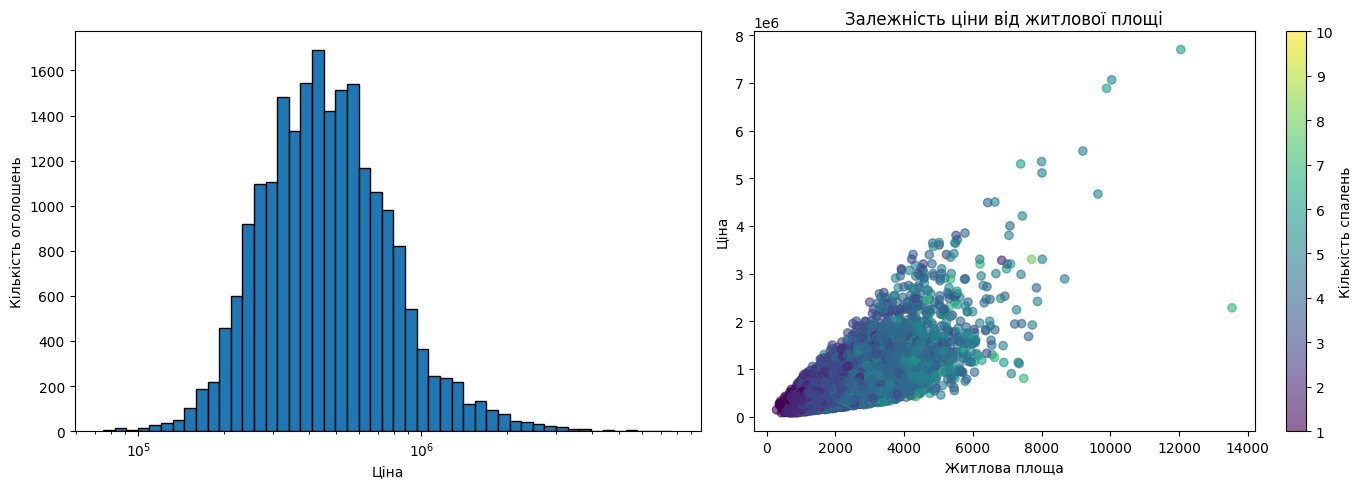

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Завдання 3 — лівий графік: гістограма ціни
bins_log = np.logspace(np.log10(sales['price'].min()), np.log10(sales['price'].max()), 50)
axes[0].hist(sales['price'], bins=bins_log, edgecolor='black')
axes[0].set_xscale('log')
axes[0].set_xlabel('Ціна')
axes[0].set_ylabel('Кількість оголошень')

# Завдання 3 — правий графік: діаграма розсіювання sqft_living vs price
scatter = axes[1].scatter(sales['sqft_living'], sales['price'], c=sales['bedrooms'], cmap='viridis', alpha=0.6, vmin=1, vmax=10)

axes[1].set_title('Залежність ціни від житлової площі')
axes[1].set_xlabel('Житлова площа')
axes[1].set_ylabel('Ціна')

cbar = fig.colorbar(scatter, ax=axes[1])
cbar.set_label('Кількість спалень')


plt.tight_layout()
plt.show()


**Спостереження (лівий графік):** Розподіл цін має близкій до нормального розподілу характер, що свідчить про те, що більшість об'єктів зосереджені в середньому ціновому сегменті, з довгим "хвостом" елітних дорогих будинків.

**Спостереження (правий графік):** Спостерігається чітка позитивна лінійна залежність між житловою площею та ціною, при цьому будинки з більшою площею та вищою ціною очікувано мають більшу кількість спалень

---
## Завдання 4 — Навчання та оцінка регресійної моделі

Розбийте дані 80/20 (`random_state=42`). Навчіть `LinearRegression` з scikit-learn для передбачення `price` за єдиною ознакою `sqft_living`.

1. Вкажіть вільний член (intercept) та коефіцієнт для `sqft_living`.
2. Обчисліть MSE і RMSE на тестовій вибірці.
3. Яка передбачувана ціна будинку площею 2 500 кв. футів?

In [54]:
# Поділ на навчальну та тестову вибірки
train_data, test_data = train_test_split(sales, test_size=0.2, random_state=42)


In [56]:
# Завдання 4 — навчіть модель, вкажіть ваги, обчисліть MSE/RMSE, передбачте ціну для 2500 кв. фут.
X_train = train_data[['sqft_living']]
y_train = train_data['price']

X_test = test_data[['sqft_living']]
y_test = test_data['price']

model = LinearRegression()
model.fit(X_train, y_train)

intercept = model.intercept_
coefficient = model.coef_[0]

print(f"Вільний член (Intercept): {intercept:,.2f}")
print(f"Коефіцієнт для sqft_living: {coefficient:,.2f}")

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"\nMSE на тестовій вибірці: {mse:,.2f}")
print(f"RMSE на тестовій вибірці: {rmse:,.2f}")


house_to_predict = pd.DataFrame({'sqft_living': [2500]})
predicted_price = model.predict(house_to_predict)[0]

print(f"\nПередбачувана ціна будинку (2500 кв. футів): {predicted_price:,.2f}")

Вільний член (Intercept): -41,999.19
Коефіцієнт для sqft_living: 279.55

MSE на тестовій вибірці: 76,484,977,061.78
RMSE на тестовій вибірці: 276,559.17

Передбачувана ціна будинку (2500 кв. футів): 656,887.76


---
## Завдання 5 — Порівняння двох моделей

Навчіть другу `LinearRegression` з ознаками: `sqft_living`, `bedrooms`, `bathrooms`, `yr_built`. Порівняйте RMSE на тестовій вибірці між Моделлю 1 та Моделлю 2. Яке значення нижче? Коротко поясніть чому.

In [68]:
# Завдання 5 — модель з чотирма ознаками та порівняння RMSE
features = ['sqft_living', 'bedrooms', 'bathrooms', 'yr_built']
X_train = train_data[features]
y_train = train_data['price']

X_test = test_data[features]
y_test = test_data['price']

model = LinearRegression()
model.fit(X_train, y_train)

intercept = model.intercept_
coefficients = model.coef_

print(f"Вільний член (Intercept): {intercept:,.2f}")
print(f"Коефіцієнти:")
for feature_name, coef in zip(features, coefficients):
    print(f"      - {feature_name}: {coef:,.2f}")

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"\nMSE на тестовій вибірці: {mse:,.2f}")
print(f"RMSE на тестовій вибірці: {rmse:,.2f}")

house_features = pd.DataFrame({
    'sqft_living': [2500],
    'bedrooms': [3],
    'bathrooms': [2],
    'yr_built' : [1990]
})
predicted_price = model.predict(house_features)[0]

print(f"\nПередбачувана ціна будинку (2500 кв.ф, 3 спальні, 2 ванні, побуд. 1990): {predicted_price:,.2f}")

Вільний член (Intercept): 6,112,448.72
Коефіцієнти:
      - sqft_living: 296.13
      - bedrooms: -68,991.68
      - bathrooms: 88,164.06
      - yr_built: -3,116.42

MSE на тестовій вибірці: 69,161,623,505.30
RMSE на тестовій вибірці: 262,985.98

Передбачувана ціна будинку (2500 кв.ф, 3 спальні, 2 ванні, побуд. 1990): 620,440.92


**Відповідь:** Ознаки bedrooms та bathrooms дуже сильно пов'язані з sqft_living. Великий будинок зазвичай і так має багато спалень та ванних, тобто алгоритм вже отримав більшу частину найважливішої інформації про розмір будинку ще у першій моделі. Додавання спалень і ванних майже не принесло нової, унікальної інформації для моделі 2 — воно просто підтвердило те, що модель і так знала з площі.

---
## ✨ Бонус — Аналіз залишків

Для вашої кращої моделі обчисліть вектор залишків (predicted − actual). Побудуйте гістограму. Чи виглядають залишки нормально розподіленими та центрованими навколо нуля? Що означав би систематичний ненульовий середній залишок?

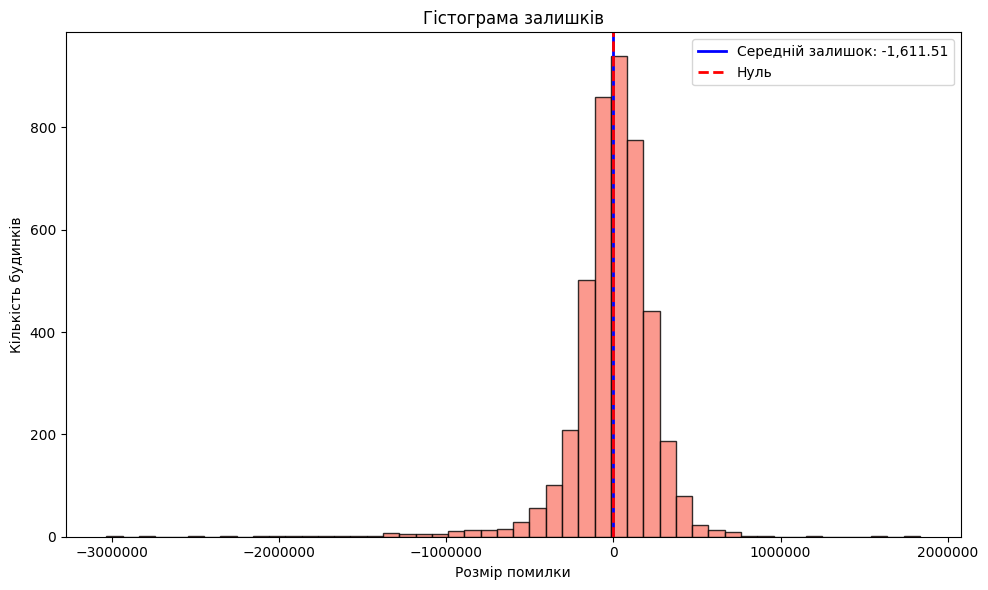

In [63]:
# Бонус — аналіз залишків
residuals = y_pred - y_test

mean_residual = np.mean(residuals)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(residuals, bins=50, edgecolor='black', color='salmon', alpha=0.8)

ax.axvline(x=mean_residual, color='blue', linestyle='-', linewidth=2, label=f'Середній залишок: {mean_residual:,.2f}')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Нуль')


ax.set_title('Гістограма залишків')
ax.set_xlabel('Розмір помилки')
ax.set_ylabel('Кількість будинків')
ax.ticklabel_format(style='plain', axis='x') 
ax.legend()

plt.tight_layout()
plt.show()

**Спостереження:** Розподіл нагадує нормальний (має чіткий пік по центру), але він не є ідеально симетричним. Модель катастрофічно недооцінила деякі дуже дорогі будинки (хвіст зліва гістограми). Вона спрогнозувала для них стандартну ціну , але насправді це були елітні маєтки. Оскільки модель не знає нічого про локацію (наприклад, поштовий індекс), вона просто не здатна правильно оцінити таку нерухомість, що і створює ці великі мінусові помилки на графіку.
Залишки центровані навколо нуля. Середній залишок становить -1,611.51$. У масштабах цін на нерухомість ця сума є невеликою. Це означає, що у моделі немає систематичного зміщення - вона не має схильності постійно завищувати або постійно занижувати ціни на більшість будинків.